## BTSP in a T-maze

* T-maze, largely fixed direction navigation, randomly selecting target arm on each trajectory
* CA3: 40 preset place fields
* CA1: 
  * Hebbian learning + BTSP learning at targeted neurons
  * BTSP learning: long-tailed (pre) Hebbian learning with a high output firing rate considered (occurs in one trajectory only)
  * (1) 1 cell, receives BTSP signal at a reward location

Evaluate resulting CA1 neuron place field properties

In [1]:
import copy
from pathlib import Path
import sys
from typing import Any
import warnings

from matplotlib import pyplot as plt
import numpy as np
import ratinabox
from tqdm import tqdm

add_paths = [str(Path(".."))]
for add_path in add_paths:
    if add_path not in sys.path:
        sys.path.append(add_path)

from predhpc import agent, env, run_manager, neurons, plot_util, util

In [2]:
plot_util.stylize_plots_for_notebook()
ratinabox.autosave_plots = False
ratinabox.figure_directory = "figures"

In [3]:
warnings.filterwarnings(
    "ignore", message="invalid value encountered", 
    category=RuntimeWarning
)

## Reload

In [4]:
import importlib
importlib.reload(agent)
importlib.reload(neurons.learning_neurons)
importlib.reload(run_manager)
importlib.reload(plot_util)
importlib.reload(util);

## T-maze BTSP

100%|██████████████████████████████████████| 4000/4000 [00:26<00:00, 153.44it/s]


Only reached the reward 7 times (target: 8).
Trajectory lengths (17) to date: 4.71 +/- 1.05 sec each
Trajectory lengths (17) to date: 235.29 +/- 52.58 steps each


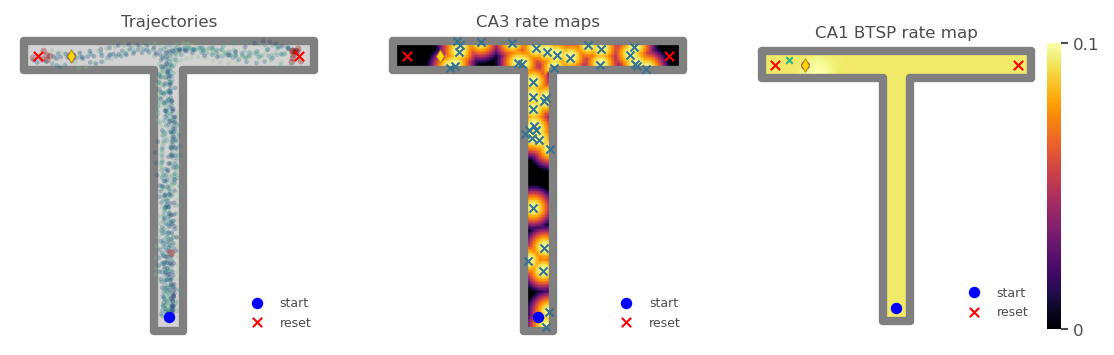

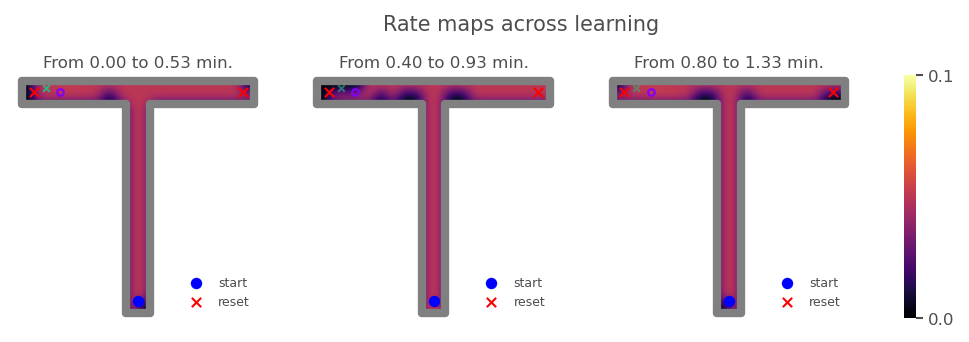

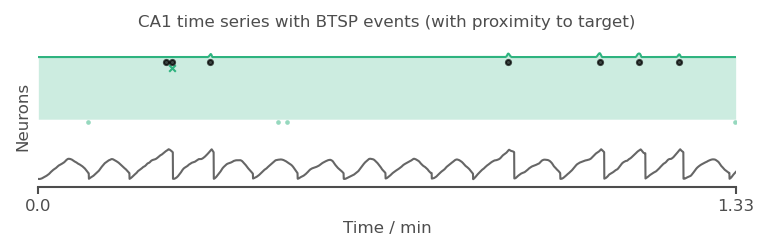

In [5]:
Env, Ag, _, CA3_PCs, CA1s = run_manager.learn_T_maze_btsp(
    run_manager.ENV_PARAMS_T_MAZE, 
    run_manager.AGENT_PARAMS_T_MAZE, 
    run_manager.CA3_PC_PARAMS_T_MAZE, 
    run_manager.CA1_PARAMS_T_MAZE, 
    num_rewards=8, 
    max_num_steps=4000, 
    weight_recording_freq=100, 
    use_Hebbian=False,
    btsp_after_num_target_reaches=2,
    two_compartment=False
)

## BTSP filtered inputs

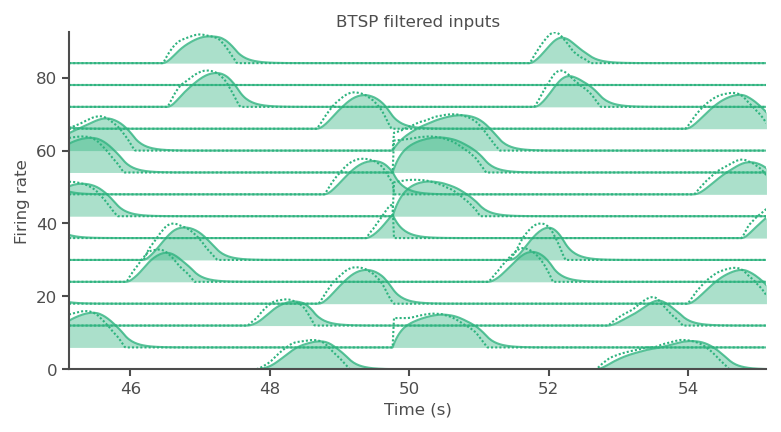

In [7]:
CA1s.plot_filtered_for_btsp("CA3_PCs", t_start=-10, chosen_neurons=np.arange(15));

## Two-compartment neuron

In [30]:
import importlib
importlib.reload(agent)
importlib.reload(neurons.learning_neurons)
importlib.reload(neurons.two_comp_neurons)
importlib.reload(run_manager)
importlib.reload(plot_util)
importlib.reload(util);

In [31]:
Ag_params = copy.copy(run_manager.AGENT_PARAMS_T_MAZE)
Ag_params["left_arm_prop"] = 1.0

CA1_two_comp_params = copy.copy(run_manager.CA1_TWO_COMP_PARAMS)

100%|██████████████████████████████████████| 4000/4000 [00:05<00:00, 708.79it/s]


Only reached the reward 16 times (target: 200).
Trajectory lengths (17) to date: 4.71 +/- 0.49 sec each
Trajectory lengths (17) to date: 235.29 +/- 24.63 steps each


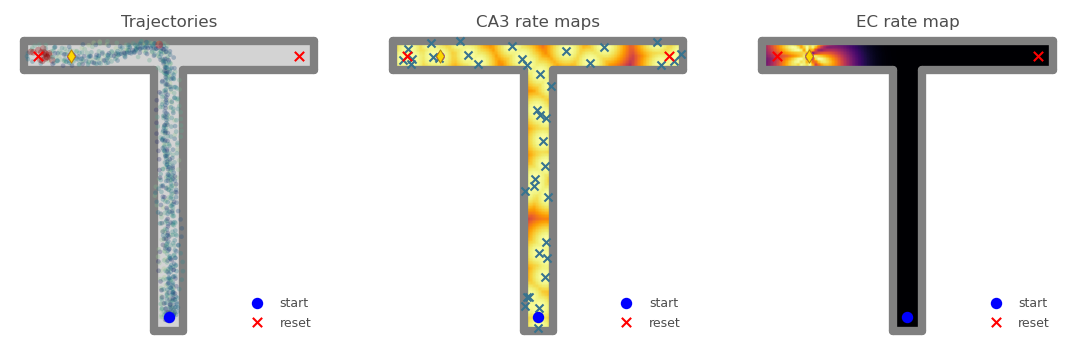

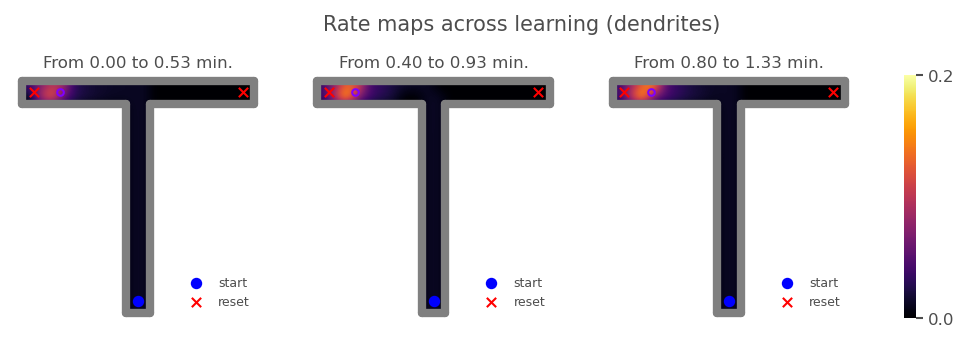

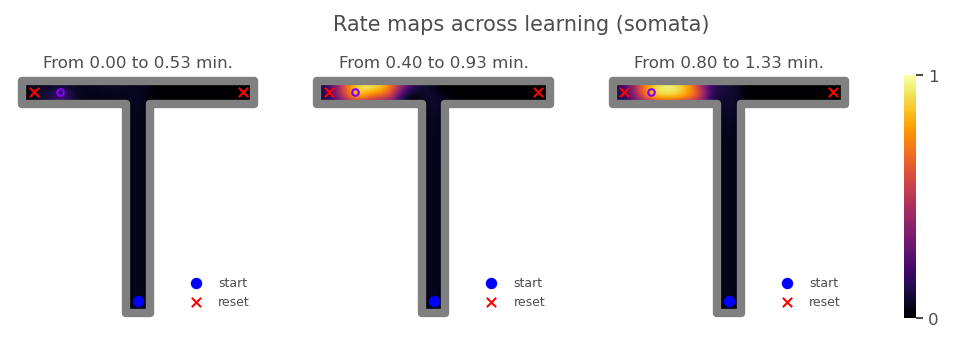

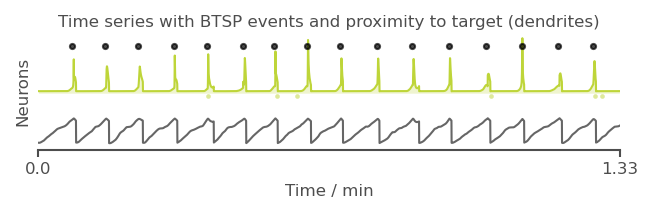

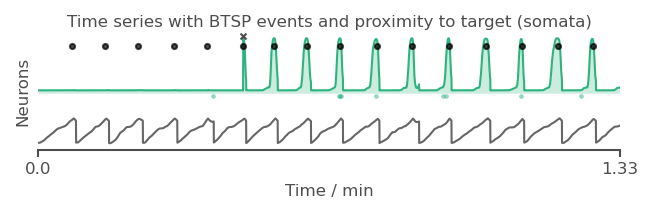

In [32]:
Env, Ag, ECs, CA3_PCs, CA1s = run_manager.learn_T_maze_btsp(
    agent_params=Ag_params,
    CA1_params=CA1_two_comp_params,
    max_num_steps=4000, 
    btsp_after_num_target_reaches=6,
    two_compartment=True,
)

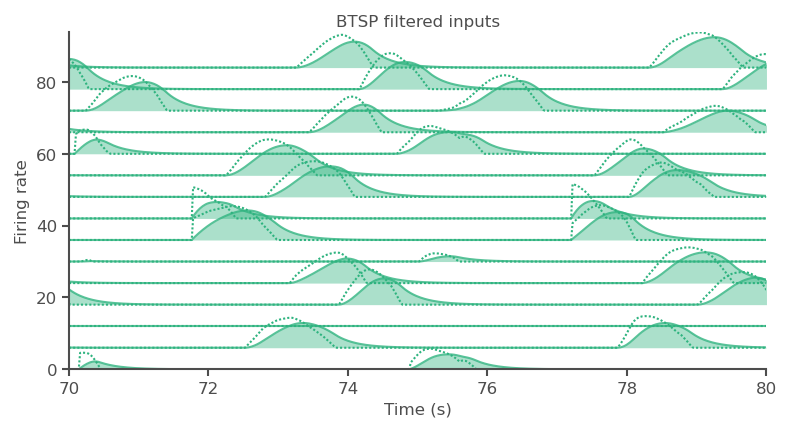

In [26]:
CA1s.SomaCompartment.plot_filtered_for_btsp("CA3_PCs", t_start=-10, chosen_neurons=np.arange(15));

## BTSP 2-compartment independent

In [102]:
from ratinabox import Environment, PlaceCells

import importlib
importlib.reload(neurons.learning_neurons)
importlib.reload(neurons.two_comp_neurons)
importlib.reload(neurons.object_neurons)
importlib.reload(run_manager)
importlib.reload(plot_util)
importlib.reload(agent)

from tqdm import tqdm

In [103]:
env_params = dict()
env_params_T_maze = copy.copy(run_manager.ENV_PARAMS_T_MAZE)
env_params_T_maze.update(env_params)

Ag_params = copy.copy(run_manager.AGENT_PARAMS_T_MAZE)
Ag_params["left_arm_prop"] = 0.8

CA3_PC_params = copy.copy(run_manager.CA3_PC_PARAMS_T_MAZE)
CA3_PC_params["place_cell_centres"] = "uniform"

CA1_params = {
    "n": 8,
    "dend_init_weights_zero": False,
    "soma_init_weights_zero": False,
    "dend_w_init_scale": 0.2, # set fairly small
    "soma_w_init_scale": 0.2, # set fairly small
    "btsp_filter_tau": run_manager.AGENT_PARAMS_1D["dt"] * 5,
    "lr": 1e-4,
    "apply_Ojas_rule": False,
    "normalize_weights": True,
    "inhibit_weight": 0.5,
    "btsp_single": True,
}

CA1_params_T_maze = copy.copy(run_manager.CA1_TWO_COMP_PARAMS)
CA1_params_T_maze.update(CA1_params)

 54%|████████████████████▍                 | 2149/4000 [00:20<00:17, 105.19it/s]


Trajectory lengths (9) to date: 4.78 +/- 0.36 sec each
Trajectory lengths (9) to date: 238.89 +/- 18.14 steps each


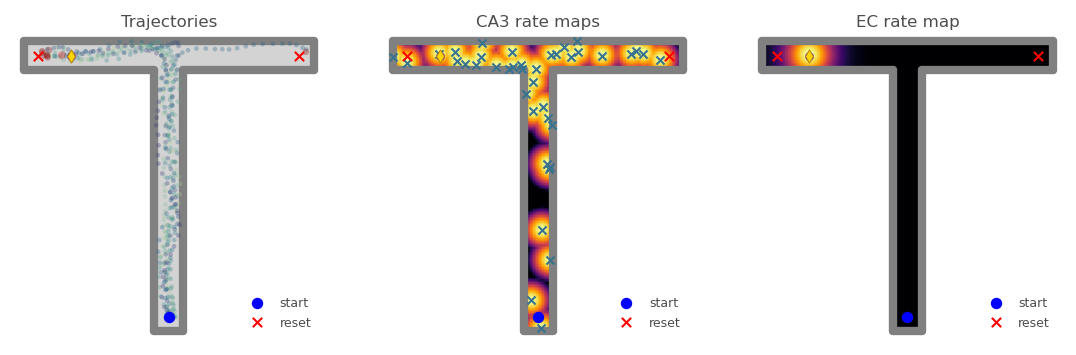

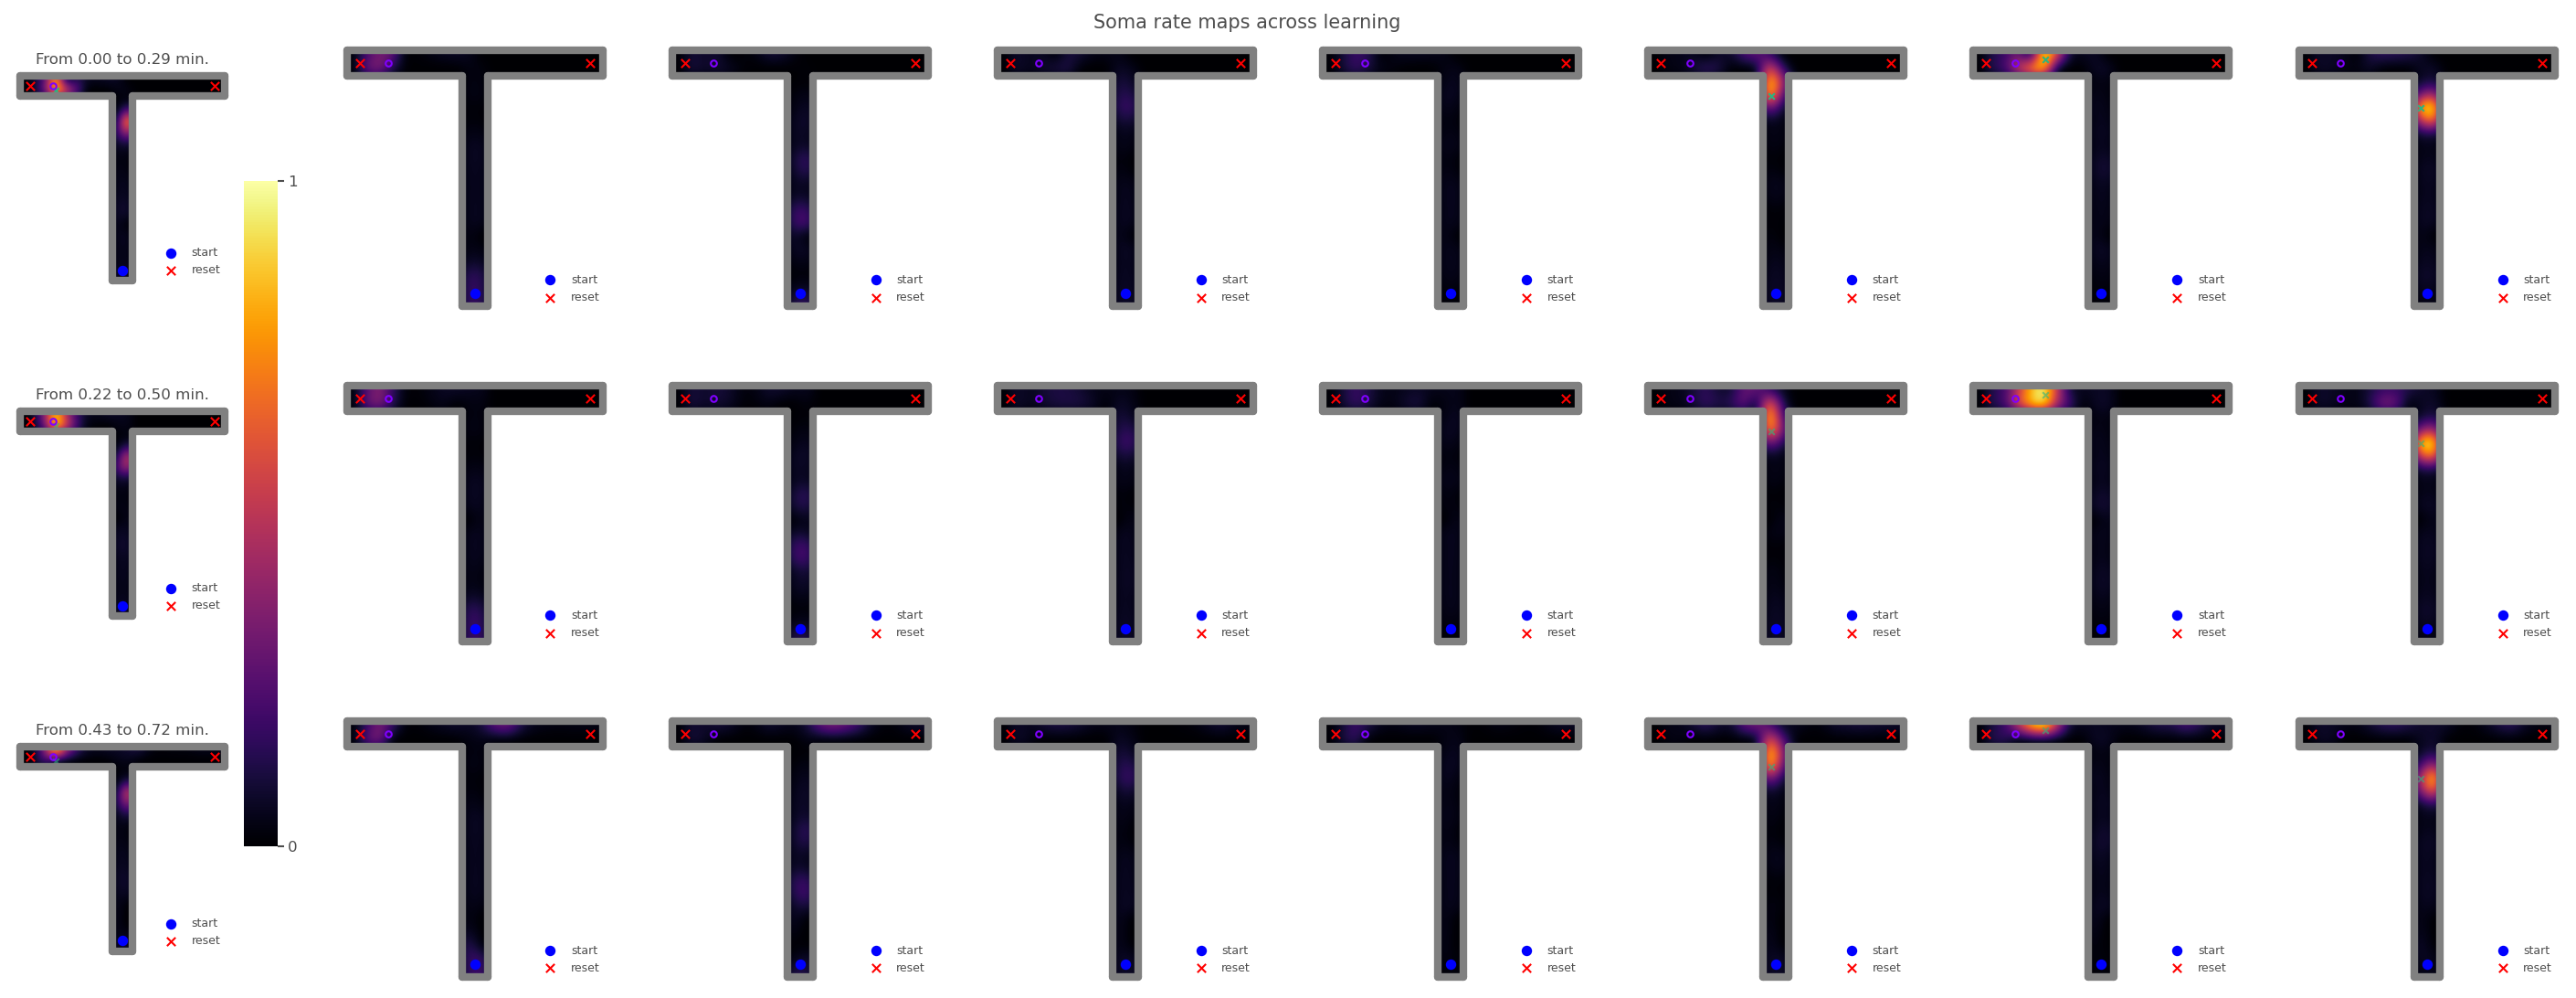

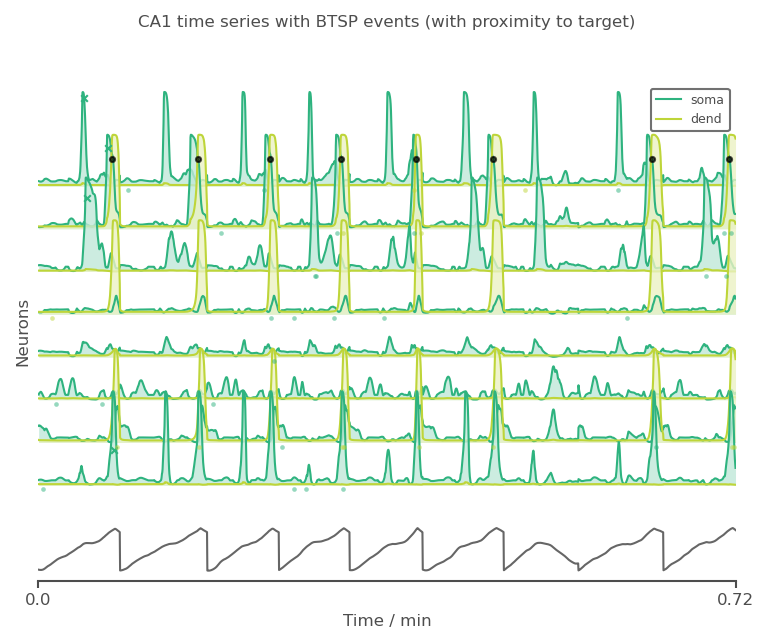

In [104]:
Env, Ag, ECs, CA3_PCs, CA1s = run_manager.learn_T_maze_btsp(
    env_params_T_maze, 
    Ag_params, 
    CA3_PC_params, 
    CA1_params_T_maze, 
    num_rewards=8, 
    max_num_steps=4000, 
    weight_recording_freq=100, 
    use_Hebbian=False,
    btsp_after_num_target_reaches=2, # ignored if 2-compartment
    two_compartment=True
)

## Look at integrating previous firing rates for FF layers (as recurrence or input smoothing)
- Enable time-dependency via fixed weights
- Fix plot_rate_maps() to avoid infinite recursion: seperate out FF from recurrent inputs?